# I - Optimal split of orders across liquidity pool 

In this notebook, we implement the stochastic approximation algorithm described on page 11 for the optimal allocation of buy orders in dark pools in a shortage configuration (i.e., the total volume available in the dark pools is smaller than the volume we want to execute, so the remaining volume is executed on the regular market).

We generate pseudo-realistic data as proposed on page 15, based on order book data from certain stocks on the Paris Stock Exchange ("BOUYGUES", "LVMH", "SANOFI", "TOTAL").

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
import math
import calendar
from scipy.stats import poisson
from sklearn.preprocessing import StandardScaler, RobustScaler
from datetime import date

In [2]:
actif_paris = ["BOUYGUES", "LVMH", "SANOFI", "TOTAL"]
bourse_paris = {actif: pd.read_hdf(f"../data/{actif}.h5") for actif in actif_paris}

In [3]:
def select_data(start, period, bourse):
    """ Choix de l'actif le plus liquide de la bourse """
    volume_max = 0
    end = start + pd.offsets.BDay(period)
    for actif in bourse:
        volume_actif = bourse[actif].loc[start: end]['TradedQty'].sum()
        if volume_actif > volume_max:
            volume_max = volume_actif
            traded_asset = actif
    asset = bourse[traded_asset].loc[start: end]
    dark_pools = {key: df.loc[start: end] for key, df in bourse.items() if key != traded_asset}
    pools = np.array(list(dark_pools.keys()))
    return traded_asset, pools, asset, dark_pools

#### I - The following functions are used to generate pseudo-realistic data


In [4]:
def sample_executed_qty(T, asset, dark_pools):
    """ Echantillonage de V et des S_i"""
    
    V = asset['TradedQty'].groupby(asset.index.date).apply(lambda x: x.resample(f'{T}s').sum().fillna(0.)).reset_index(level=0, drop=True)
    V_df = V.copy()
    S_i = {key: df['TradedPrice'].groupby(df.index.date).apply(lambda x: x.resample(f'{T}s').mean().ffill()).reset_index(level=0, drop=True) for key, df in dark_pools.items() }
    S = asset['TradedPrice'].groupby(asset.index.date).apply(lambda x: x.resample(f'{T}s').mean().ffill()).reset_index(level=0, drop=True)
    return V_df, V.values, pd.DataFrame(S_i).values, S.values


def choose_beta(dark_pools, beta_sum):
    """ Construction des beta_i de sorte que la somme soit égale à beta_sum """
    
    N = len(dark_pools)
    bet = math.floor(100*beta_sum/N)/100
    beta_i = bet*np.ones(N)
    if N > 1:
        beta_i[-1] = beta_sum - (N-1)*bet
    return pd.DataFrame([beta_i]).values[0]


def compute_D(V, S_i, beta_i, alpha_i):
    """ Calcul de D_i, liquidité disponibles dans les dark pool """
    E_V = V.mean()
    E_S_i = S_i.mean(axis=0)
    D_i = beta_i[None,:] * ( (1-alpha_i[None,:])*V[:,None] + alpha_i[None,:]*S_i*E_V/E_S_i[None,:])
    return D_i

#### II - The following functions are used to construct $H$, implement the stochastic gradient algorithm, and compute the cost of the strategy.

The gradient descent step size is chosen as follows:

$$
\gamma_n = \frac{\gamma_0}{n} \quad \text{for} \quad n \in \{1, 2, \dots\}
$$

Such a step size satisfies the conditions for a decreasing step.


In [5]:
def H(V_n, S_n, r_i_n, D_i_n, rho_i):
    """ Calcule de H """
    rho_ind_i_n = rho_i*(r_i_n*V_n < D_i_n)
    h = S_n*V_n*(rho_ind_i_n - rho_ind_i_n.mean())
    return h



def opt_alloc_algo(V, S, D_i, rho_i, V_df, gam0, param_reset=False):
    """ Implémentation de l'algortithme de gradient stochastique """
    def gamma_fun(x):
        n = np.arange(2, len(x)+2)
        return gam0/n
    
    gam_stand = gamma_fun(V)
    gam_reset = V_df.groupby(V_df.index.date).transform(lambda x: gamma_fun(x)).values
    
    N = len(rho_i)
    horizon = len(V)
    r_i = (1/N)*np.ones((horizon,N))
    for n in range(1,horizon):
        gam = gam_reset[n] if param_reset else gam_stand[n]  
        r = r_i[n-1,:] + gam * H(V[n], S[n], r_i[n-1], D_i[n], rho_i)
        if r.sum() > 0:
            r_i[n,:] = r / r.sum()
        else:
            r_i[n,:] = (1/N) * np.ones(N)
    return r_i


def compute_cost(V, S, r_i, D_i, rho_i):
    """ Calcul du coût associé à une stratégie r_i"""
    C = S * ( V - (rho_i[None,:]*np.minimum(r_i*V[:,None], D_i)).sum(axis=1) )
    return C

#### III - The following function defines the oracle strategy:

Knowing the volumes and prices in each dark pool, it ranks the dark pools in ascending order of prices and allocates the maximum possible in the dark pool offering the lowest price until the maximum available liquidity is consumed. The remainder is allocated to the regular market.


In [6]:
def oracle_strat(V, S, D_i, rho_i):
    """ Stratégie de l'oracle """
    horizon = len(V)
    P_i = S[:,None]*(1-rho_i[None,:])
    darkpool_rank = np.argsort(P_i, axis=1)
    vol_i_ora = np.zeros_like(P_i, dtype=float)  
    for n in range(horizon): 
        remain_V = V[n]
        for i in darkpool_rank[n]:  
            if remain_V <= 0:
                break 
            alloc = min(remain_V, D_i[n, i])  
            vol_i_ora[n, i] = alloc
            remain_V -= alloc 
    r_i_ora = np.divide(vol_i_ora, V[:, None], where=(V[:, None] != 0))
    return r_i_ora

#### IV - Here, we define the global functions and introduce the calculation of performance metrics such as the Cost Reduction, defined by:

$$
CR_{strat} = \frac{V \cdot S - Cost_{strat}}{V \cdot S}
$$

It measures the level of satisfaction.

We also compute the performance ratio relative to that of the oracle:

$$
ratio = \frac{CR_{strat}}{CR_{oracle}}
$$


In [7]:
def global_opt_alloc_algo(T, beta_i, alpha_i, rho_i, asset, dark_pools, gam0):
    V_df, V, S_i, S = sample_executed_qty(T, asset, dark_pools)
    D_i = compute_D(V, S_i, beta_i, alpha_i)
    
    r_i_lt = opt_alloc_algo(V, S, D_i, rho_i, V_df, gam0, param_reset=False)  # long term
    r_i_res = opt_alloc_algo(V, S, D_i, rho_i, V_df, gam0, param_reset=True)  # avec reset journalier du pas
    r_i_ora = oracle_strat(V, S, D_i, rho_i)                                  # strat de l'oracle
    
    C_S = S*V
    CR_algo_lt = 1 - compute_cost(V, S, r_i_lt, D_i, rho_i)/C_S
    CR_algo_res = 1 - compute_cost(V, S, r_i_res, D_i, rho_i)/C_S
    CR_ora = 1 - compute_cost(V, S, r_i_ora, D_i, rho_i)/C_S
    
    days = V_df.index
    return r_i_lt, r_i_res, r_i_ora, CR_algo_lt, CR_algo_res, CR_ora, days


In [8]:
def plot_cost_perf(beta_i, alpha_i, rho_i, CR_algo_lt, CR_algo_res, CR_ora, start, T, days, traded_asset, pools):
    
    fig, axs = plt.subplots(1, 2, figsize=(20, 5))
    pools_list = ', '.join([pools[i] for i in range(len(pools))])
    rho_list = ', '.join([f"{rho_i[i]:.2f}" for i in range(len(rho_i))])
    beta_list = ', '.join([f"{beta_i[i]:.2f}" for i in range(len(beta_i))])
    alpha_list = ', '.join([f"{alpha_i[i]:.2f}" for i in range(len(alpha_i))])
    fig.suptitle(f'start={start.strftime("%Y-%m-%d")}, T={T}s, asset:{traded_asset}, pools: {pools_list}, $\\rho$:{rho_list}, $\\beta$: {beta_list}, $\\alpha$: {alpha_list}', fontsize=16)
    x = np.arange(len(days))
    unique_days = np.unique(days.date)  
    last_indices = [np.where(days.date == d)[0][-1] for d in unique_days]
    x_ticks_labels = np.arange(len(unique_days)) + 1

    # Calcul des ratios
    ratio_ora = np.ones_like(CR_ora)
    ratio_lt = np.divide(CR_algo_lt, CR_ora, where=(CR_ora != 0), out=np.full_like(CR_ora, np.nan))
    ratio_res = np.divide(CR_algo_res, CR_ora, where=(CR_ora != 0), out=np.full_like(CR_ora, np.nan))

    # Premier graphique : Réductions relatives de coûts
    axs[0].plot(x, 100 * CR_ora, c='black', alpha=0.8, label='Oracle')
    axs[0].plot(x, 100 * CR_algo_lt, c='blue', alpha=0.8, label='Algo without reset')
    axs[0].plot(x, 100 * CR_algo_res, c='red', alpha=0.6, label='Algo with reset')
    axs[0].set_title('Relative cost reductions')
    axs[0].set_xlabel('Days')
    axs[0].set_ylabel('Satisfaction (%)')
    axs[0].set_xticks(last_indices)  
    axs[0].set_xticklabels(x_ticks_labels)
    for xc in last_indices:
        axs[0].axvline(x=xc, color='gray', linestyle=':', alpha=0.5)
    axs[0].legend()
    
    # Deuxième graphique : Performances
    axs[1].plot(x, 100 * ratio_ora, c='black', alpha=0.8, label='Oracle')
    axs[1].plot(x, 100 * ratio_lt, c='blue', linestyle='--', alpha=0.8, label='Algo without reset')
    axs[1].plot(x, 100 * ratio_res, c='red', linestyle='--', alpha=0.6, label='Algo with reset')
    axs[1].set_title('Performances')
    axs[1].set_xlabel('Days')
    axs[1].set_ylabel('Ratios (%)')
    axs[1].set_xticks(last_indices)  
    axs[1].set_xticklabels(x_ticks_labels)
    for xc in last_indices:
        axs[1].axvline(x=xc, color='gray', linestyle=':', alpha=0.5)
    axs[1].legend()

    plt.tight_layout()
    plt.show()

In [ ]:
start = pd.Timestamp("2011-01-01")
period = 10  # number of days
traded_asset, pools, asset, dark_pools = select_data(start, period, bourse_paris)
N = len(dark_pools)
beta_sum = 0.8
beta_i = choose_beta(dark_pools, beta_sum)
alpha_i = np.linspace(0.2, 0.8, N)
rho_i = np.linspace(0.01, 0.03, N)

gam0 = 1e-7

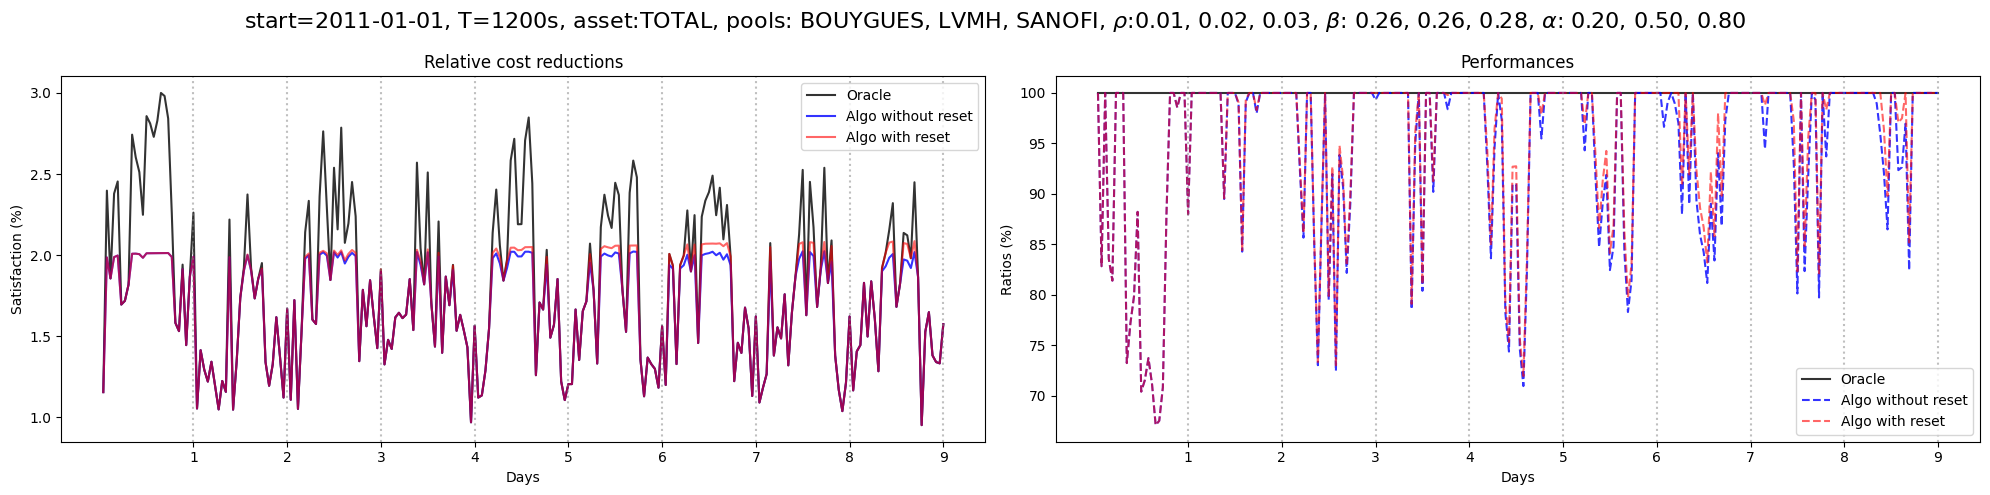

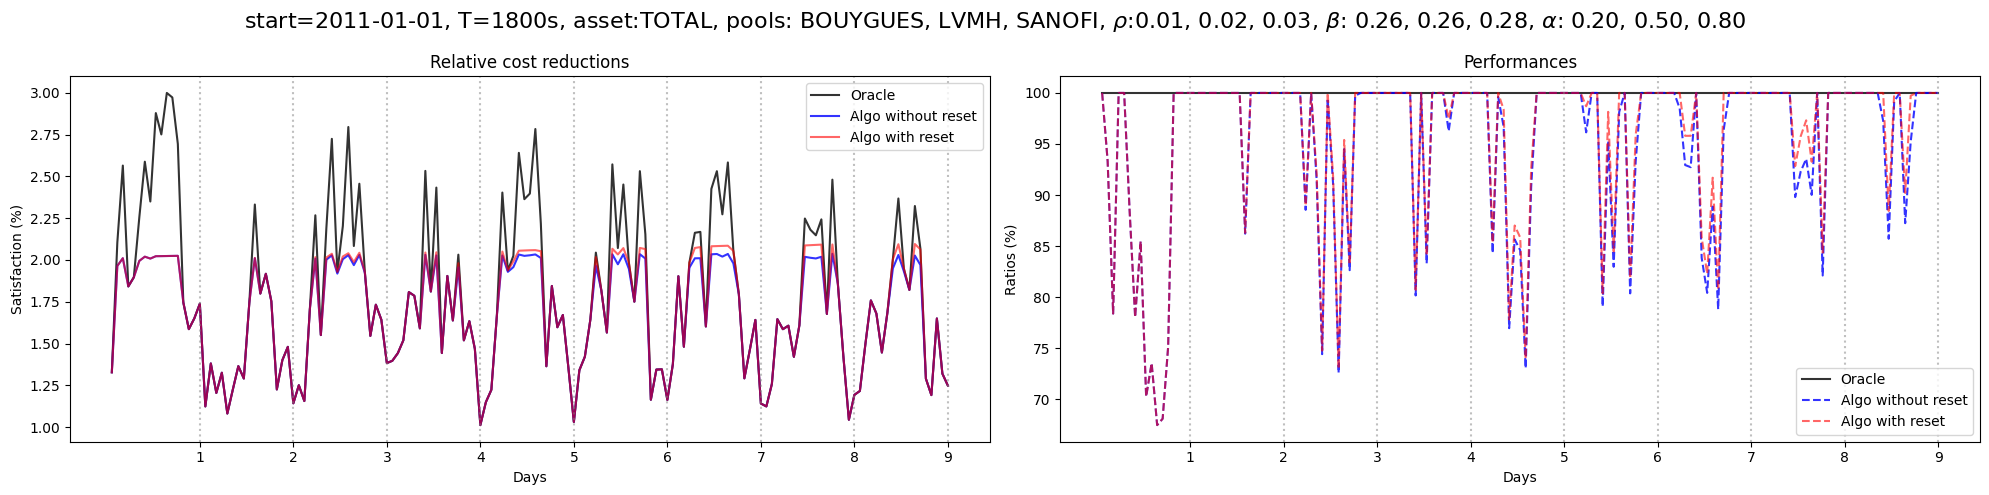

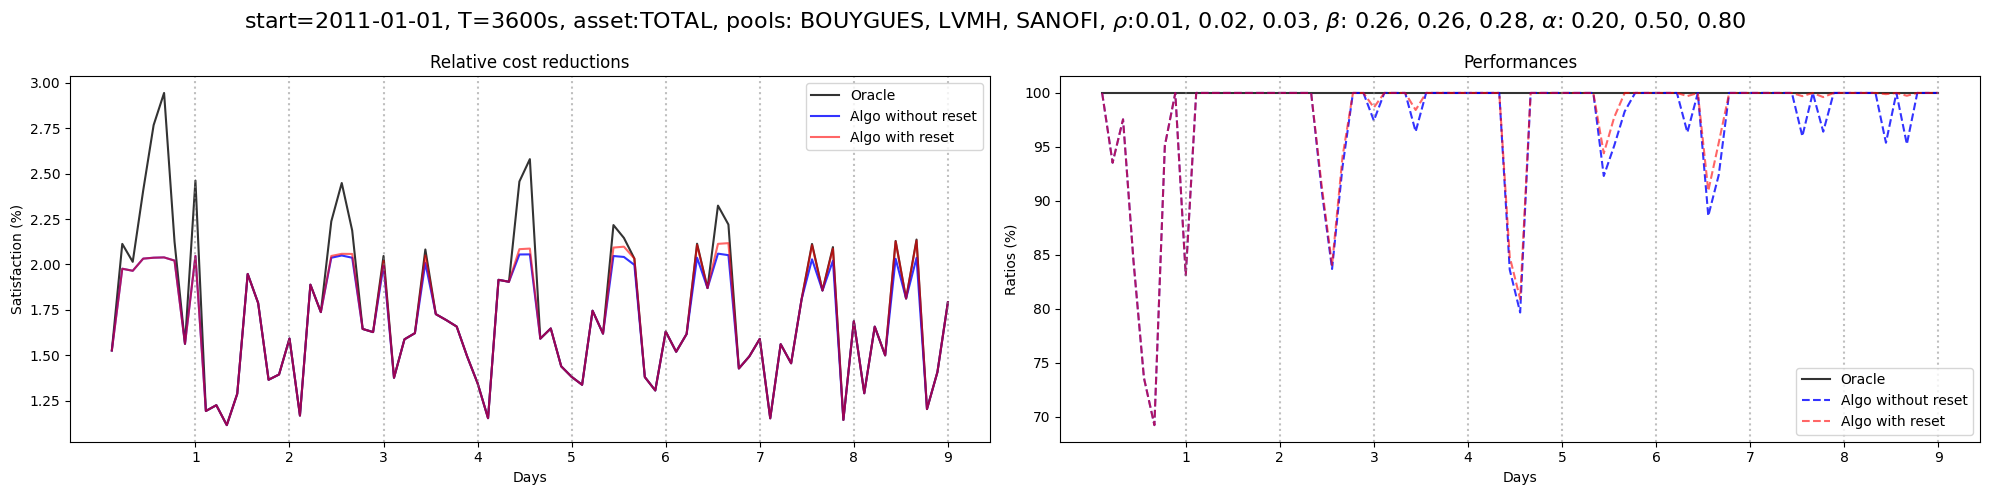

In [10]:
T_list = 60*np.array([20, 30, 60])
for T in T_list:
    r_i_lt, r_i_res, r_i_ora, CR_algo_lt, CR_algo_res, CR_ora, days = global_opt_alloc_algo(T, beta_i, alpha_i, rho_i, 
                                                                                                        asset, dark_pools, gam0)
    plot_cost_perf(beta_i, alpha_i, rho_i, CR_algo_lt, CR_algo_res, CR_ora, start, T, days, traded_asset, pools)

##### Comments: We observe that for any frequency, the oracle achieves a higher satisfaction rate. Moreover, resetting the step size $\gamma$ at the beginning of each day slightly improves the strategy's performance.


#### V - We examine the evolution of the allocation over time for various shortage scenarios and for different combinations of $\rho_i$ in the pools in the case of an optimization **without daily reset** of the step size.

We fix a frequency $T = 5$ min


In [11]:
def plot_allocation(r_i_lt_list, beta_i_list, rho_i, start, T, days, pools):
    fig, axs = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f'start={start.strftime("%Y-%m-%d")}, T={T}s, asset:{traded_asset}', fontsize=16)
    x = np.arange(len(days))
    unique_days = np.unique(days.date)  
    last_indices = [np.where(days.date == d)[0][-1] for d in unique_days]
    x_ticks_labels = np.arange(len(unique_days)) + 1

    for j in range(len(r_i_lt_list)):
        axs[j].plot(x, r_i_lt_list[j][:,0], label=f"pool {pools[0]}: $\\beta$={beta_i_list[j][0]:.2f}, $\\rho$={rho_i[0]:.2f}")
        axs[j].plot(x, r_i_lt_list[j][:,1], label=f"pool {pools[1]}: $\\beta$={beta_i_list[j][1]:.2f}, $\\rho$={rho_i[1]:.2f}")
        axs[j].plot(x, r_i_lt_list[j][:,2], label=f"pool {pools[2]}: $\\beta$={beta_i_list[j][2]:.2f}, $\\rho$={rho_i[2]:.2f}")
        axs[j].set_title(f'$\\beta$ sum = {beta_i_list[j].sum():.2f}')
        axs[j].set_xlabel('Days')
        axs[j].set_ylabel('allocation weights')
        axs[j].set_xticks(last_indices)  
        axs[j].set_xticklabels(x_ticks_labels)
        for xc in last_indices:
            axs[j].axvline(x=xc, color='gray', linestyle=':', alpha=0.5)
        axs[j].legend()
    
    plt.tight_layout()
    plt.show()

In [12]:
T = 60*2
beta_sums = np.array([0.5, 0.65, 0.8])
r_i_lt_list1, r_i_lt_list2 = [], []
beta_i_list = []
rho_i1 = np.array([0.1, 0.2, 0.3])
rho_i2 = np.array([0.3, 0.2, 0.1])
for beta_sum in beta_sums:
    beta_i = choose_beta(dark_pools, beta_sum)
    beta_i_list.append(beta_i)
    r_i_lt1, _, _, _, _, _, days = global_opt_alloc_algo(T, beta_i, alpha_i, rho_i1, asset, dark_pools, gam0)
    r_i_lt2, _, _, _, _, _, days = global_opt_alloc_algo(T, beta_i, alpha_i, rho_i2, asset, dark_pools, gam0)
    r_i_lt_list1.append(r_i_lt1)
    r_i_lt_list2.append(r_i_lt2)

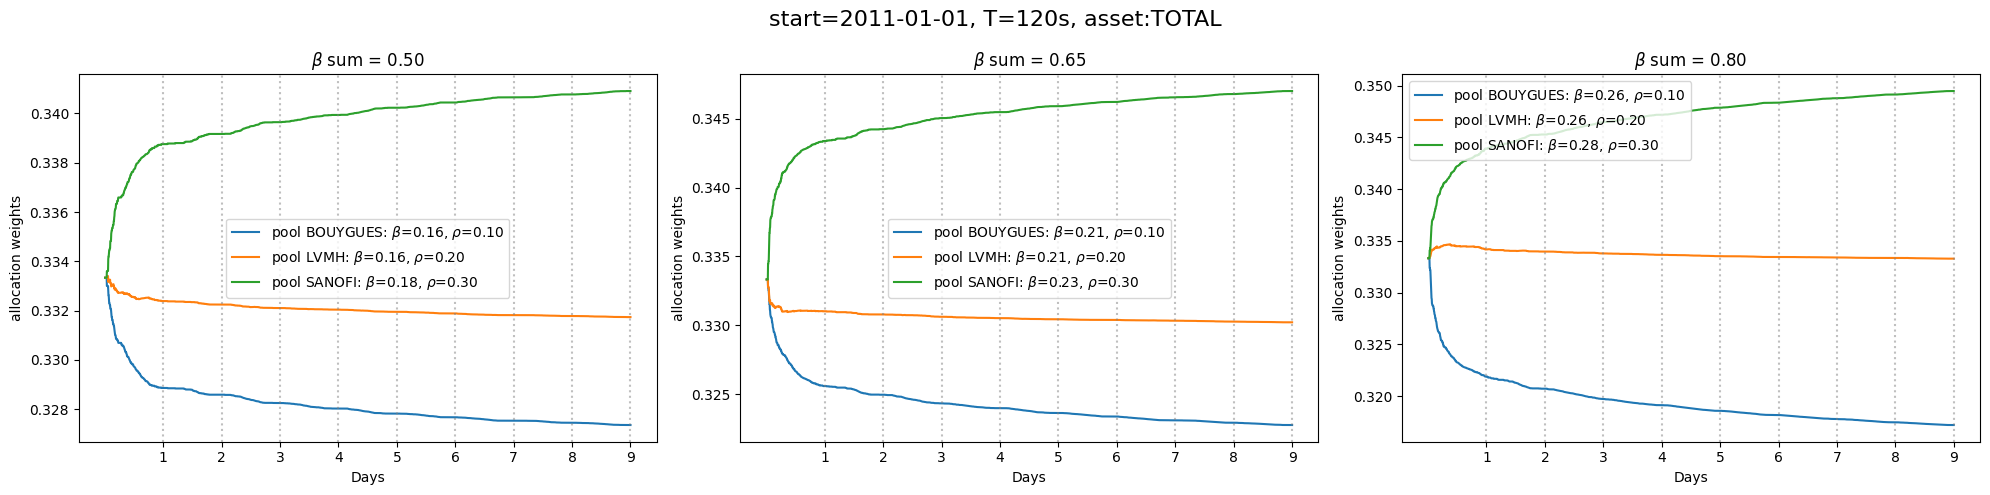

In [13]:
plot_allocation(r_i_lt_list1, beta_i_list, rho_i1, start, T, days, pools)

#### Comments: In this first case, we observe a much higher allocation to the pools offering a low price (high $\rho$) and better liquidity (high $\beta$).


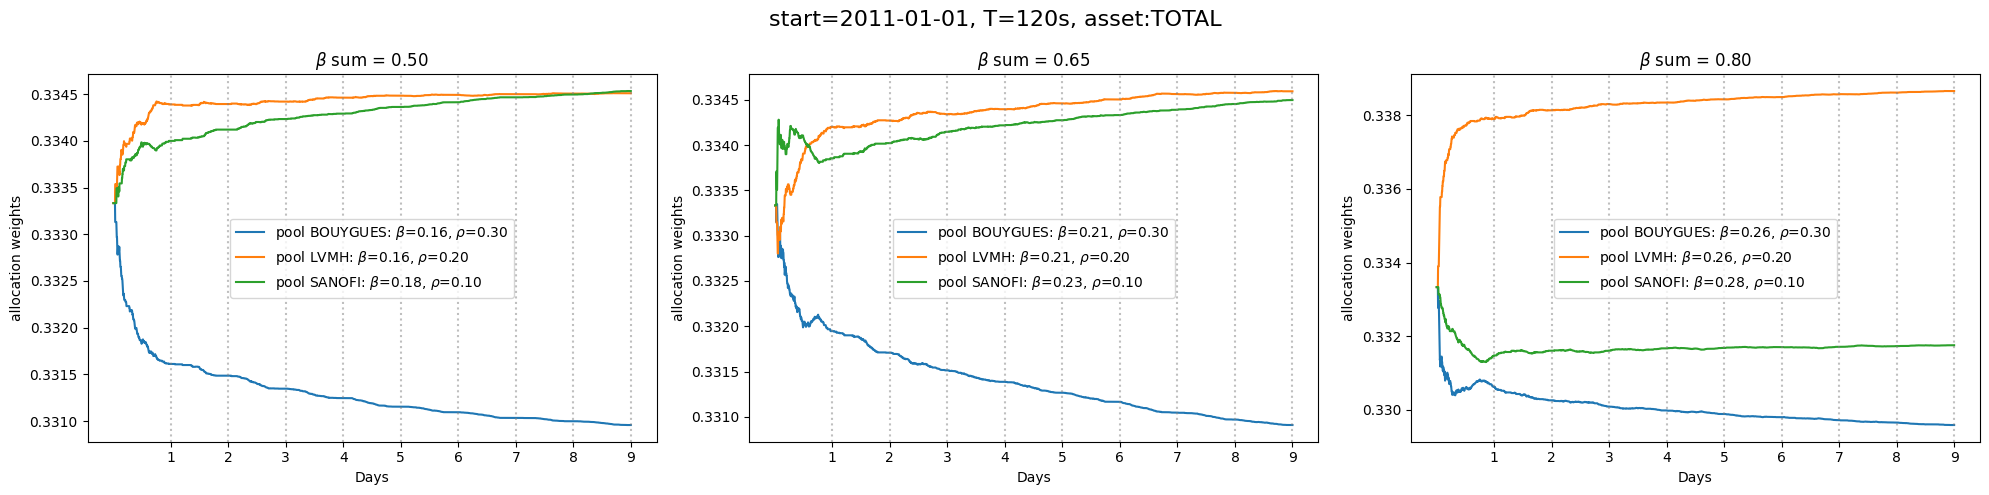

In [14]:
plot_allocation(r_i_lt_list2, beta_i_list, rho_i2, start, T, days, pools)

#### Comments: In this second case, the pools offering the most advantageous prices (high $\rho$) have lower liquidity (low $\beta$). We observe that the algorithm allocates more to the pools that provide a good balance between the two criteria, with a preference for the price criterion.
